In [1]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

def profile_transpile(circ, basis_gates=("rz","sx","x","cx"), opt_level=3):
    pm = generate_preset_pass_manager(
        optimization_level=opt_level,
        basis_gates=list(basis_gates),
    )

    log = []

    def cb(pass_, dag, time, property_set, count):
        # DAG上で数える（より正確）
        cx = sum(1 for n in dag.op_nodes() if n.name in ("cx","cz","swap","ecr","iswap","rxx","ryy","rzz"))
        depth = dag.depth()
        log.append((count, pass_.name(), cx, depth, float(time)))

    out = pm.run(circ, callback=cb)
    return out, log


In [2]:
def summarize_log(log):
    # (count, name, cx, depth, time)
    delta = []
    for i in range(1, len(log)):
        _, name, cx_prev, d_prev, _ = log[i-1]
        _, _,    cx_now,  d_now,  t = log[i]
        delta.append((cx_now - cx_prev, d_now - d_prev, t, name))
    # cxが減った順（負が良い）
    delta.sort(key=lambda x: x[0])
    return delta[:30]

In [3]:
from __future__ import annotations

from typing import Any, Dict, List, Tuple

from qiskit import QuantumCircuit
from qiskit.converters import dag_to_circuit

# Qiskitのバージョン差を吸収（どちらかで入るはず）
try:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
except Exception:  # pragma: no cover
    from qiskit.transpiler import generate_preset_pass_manager  # type: ignore


TWOQ_NAMES = {"cx", "cz", "swap", "iswap", "ecr", "rxx", "ryy", "rzz"}


def _count_twoq_in_dag(dag) -> int:
    # DAGCircuit の op_nodes() を使うのが一番安定
    c = 0
    for n in dag.op_nodes():
        if n.name.lower() in TWOQ_NAMES:
            c += 1
    return c


def run_with_callback_log(
    qc: QuantumCircuit,
    basis_gates: Tuple[str, ...] = ("rz", "sx", "x", "cx"),
    optimization_level: int = 3,
) -> Tuple[QuantumCircuit, List[Dict[str, Any]]]:
    """
    preset pass manager を callback 付きで走らせる。
    戻り値: (最終回路, ログlist)
    """
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        basis_gates=list(basis_gates),
    )

    log: List[Dict[str, Any]] = []

    # callback のシグネチャは基本これ（pass_, dag, time, property_set, count）
    def cb(pass_, dag, time, property_set, count):
        try:
            twoq = _count_twoq_in_dag(dag)
            depth = dag.depth()
        except Exception:
            # 念のため：DAG→Circuitに変換して計測
            circ = dag_to_circuit(dag)
            ops = circ.count_ops()
            twoq = sum(int(ops.get(g, 0)) for g in TWOQ_NAMES)
            depth = circ.depth()

        name = pass_.name() if hasattr(pass_, "name") else pass_.__class__.__name__
        log.append(
            {
                "i": int(count),
                "pass": str(name),
                "twoq": int(twoq),
                "depth": int(depth),
                "time_sec": float(time) if time is not None else None,
            }
        )

    out = pm.run(qc, callback=cb)
    return out, log


def print_top_drops(log: List[Dict[str, Any]], topk: int = 20) -> None:
    """
    2Qゲート数が大きく減ったパス順に表示
    """
    deltas = []
    for i in range(1, len(log)):
        prev = log[i - 1]
        cur = log[i]
        deltas.append(
            {
                "i": cur["i"],
                "pass": cur["pass"],
                "delta_twoq": cur["twoq"] - prev["twoq"],
                "delta_depth": cur["depth"] - prev["depth"],
                "twoq": cur["twoq"],
                "depth": cur["depth"],
                "time_sec": cur["time_sec"],
            }
        )
    deltas.sort(key=lambda r: r["delta_twoq"])  # 減少(負)が大きい順
    for r in deltas[:topk]:
        print(r)


# -------------------- 使い方例 --------------------
if __name__ == "__main__":
    # 例: 適当な回路
    qc = QuantumCircuit(5)
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 3)
    qc.cx(3, 4)
    qc.cx(1, 2)

    out, log = run_with_callback_log(qc, optimization_level=3)

    print("final twoq/depth:", log[-1]["twoq"], log[-1]["depth"])
    print_top_drops(log, topk=15)

    # 全ログを見たいなら
    # for r in log: print(r)

final twoq/depth: 4 3
{'i': 7, 'pass': 'InverseCancellation', 'delta_twoq': -2, 'delta_depth': -3, 'twoq': 4, 'depth': 3, 'time_sec': 1.7881393432617188e-05}
{'i': 1, 'pass': 'UnitarySynthesis', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 3.814697265625e-06}
{'i': 2, 'pass': 'HighLevelSynthesis', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 7.152557373046875e-06}
{'i': 3, 'pass': 'BasisTranslator', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 3.2901763916015625e-05}
{'i': 4, 'pass': 'ElidePermutations', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 9.775161743164062e-06}
{'i': 5, 'pass': 'RemoveDiagonalGatesBeforeMeasure', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 7.152557373046875e-06}
{'i': 6, 'pass': 'RemoveIdentityEquivalent', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 6, 'depth': 6, 'time_sec': 5.9604644775390625e-06}
{'i': 8, 'pass': 'ContractIdleWiresIn

In [4]:
import matplotlib.pyplot as plt

def plot_pass_deltas(deltas, title_prefix="Qiskit pass profiling"):
    """
    deltas: List[dict] 例: {'i':7,'pass':'InverseCancellation','delta_twoq':-2,...,'twoq':4,'depth':3}
    """
    # 実行順に並べる（print_top_dropsの出力を貼った場合、順番が崩れているので）
    rows = sorted(deltas, key=lambda r: r["i"])

    xs = list(range(len(rows)))
    pass_names = [r["pass"] for r in rows]
    d2 = [r["delta_twoq"] for r in rows]
    dd = [r["delta_depth"] for r in rows]
    twoq = [r["twoq"] for r in rows]
    depth = [r["depth"] for r in rows]

    # 1) delta_twoq の棒グラフ
    plt.figure(figsize=(max(10, len(rows) * 0.6), 4))
    plt.bar(xs, d2)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs, pass_names, rotation=60, ha="right")
    plt.ylabel("delta_twoq (negative = improvement)")
    plt.title(f"{title_prefix}: delta_twoq per pass")
    plt.tight_layout()

    # 2) twoq の推移（折れ線）
    plt.figure(figsize=(max(10, len(rows) * 0.6), 4))
    plt.plot(xs, twoq, marker="o")
    plt.xticks(xs, pass_names, rotation=60, ha="right")
    plt.ylabel("twoq (after pass)")
    plt.title(f"{title_prefix}: twoq progression")
    plt.tight_layout()

    # 3) depth の推移（折れ線）
    plt.figure(figsize=(max(10, len(rows) * 0.6), 4))
    plt.plot(xs, depth, marker="o")
    plt.xticks(xs, pass_names, rotation=60, ha="right")
    plt.ylabel("depth (after pass)")
    plt.title(f"{title_prefix}: depth progression")
    plt.tight_layout()

    # 4) delta_depth の棒グラフ（任意）
    plt.figure(figsize=(max(10, len(rows) * 0.6), 4))
    plt.bar(xs, dd)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs, pass_names, rotation=60, ha="right")
    plt.ylabel("delta_depth (negative = improvement)")
    plt.title(f"{title_prefix}: delta_depth per pass")
    plt.tight_layout()

    plt.show()

final twoq/depth: 180 88


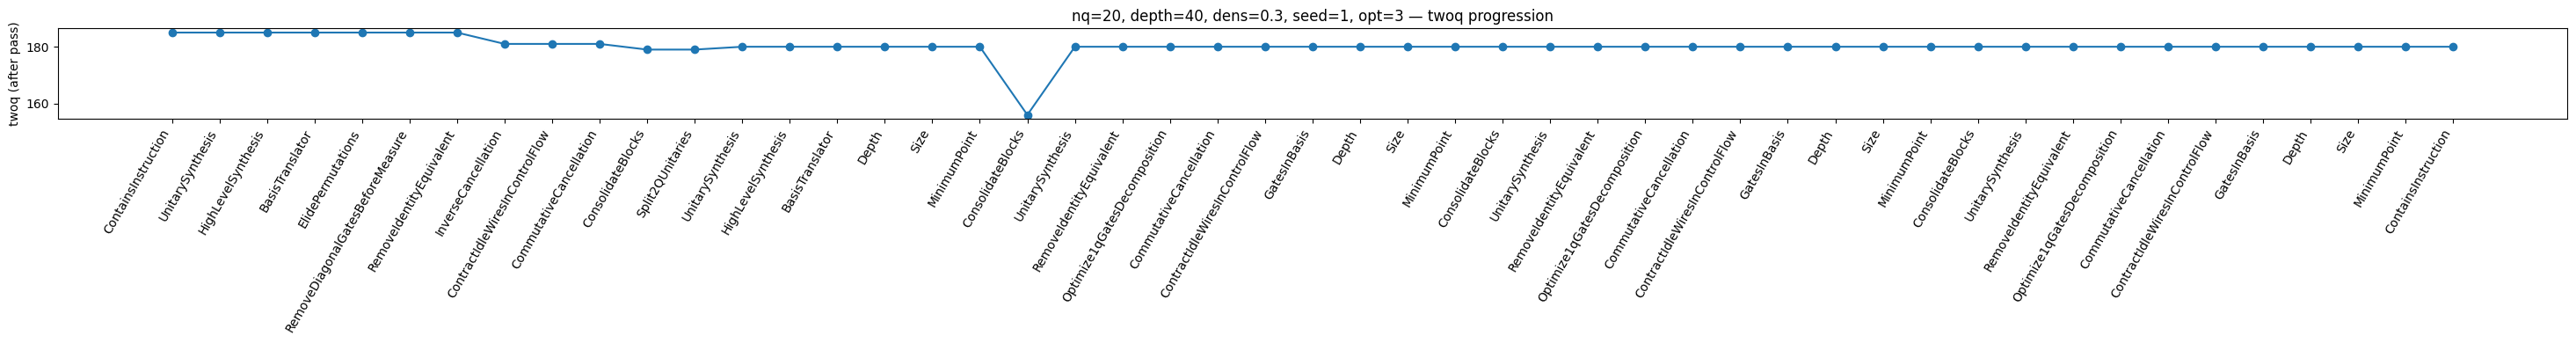

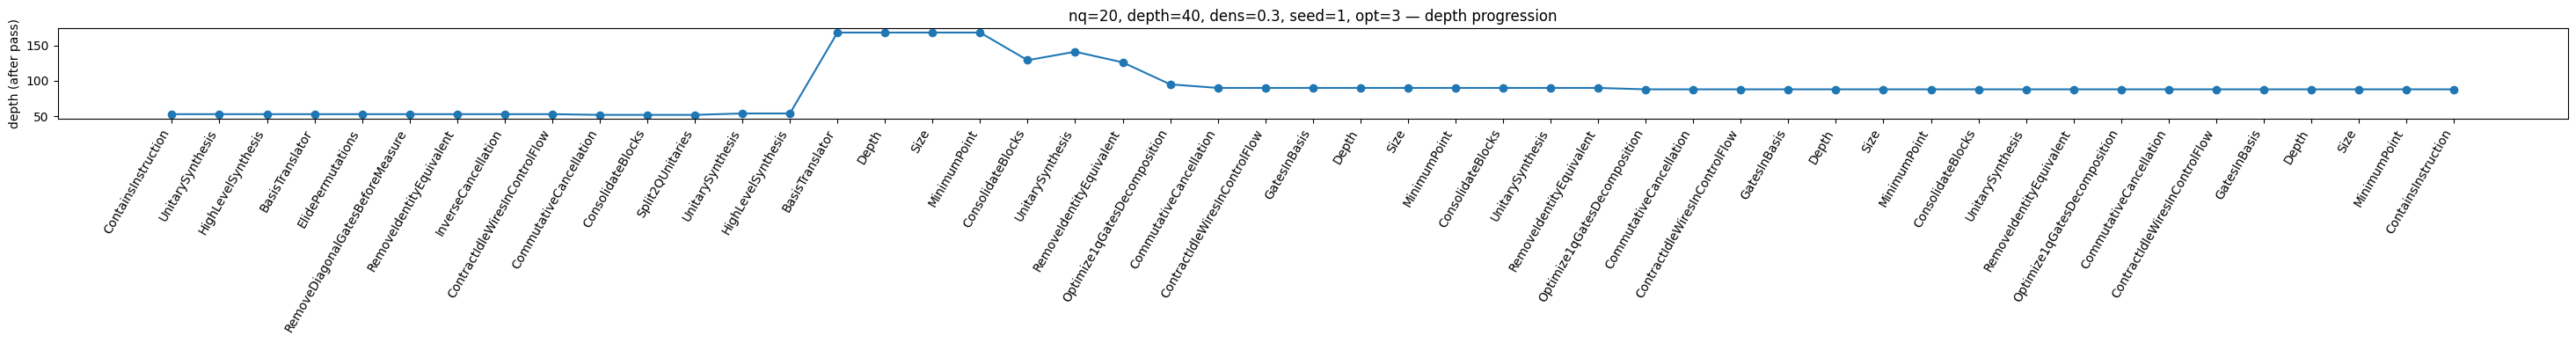

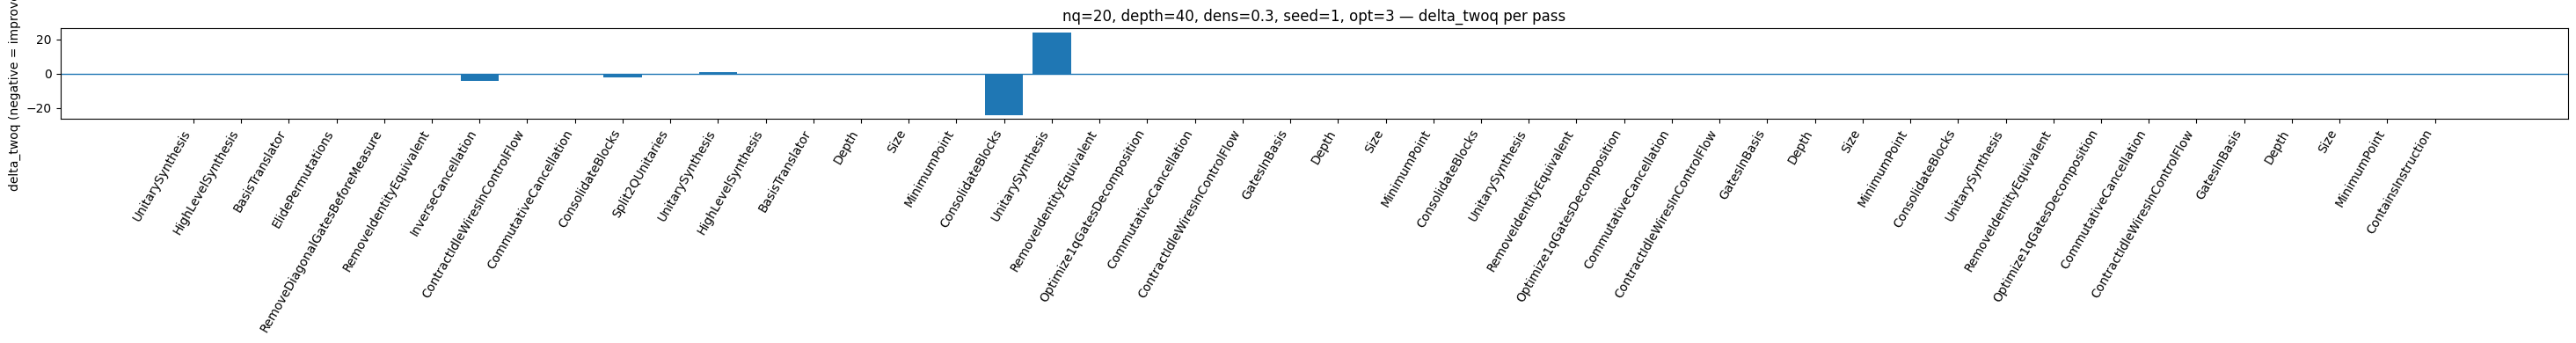

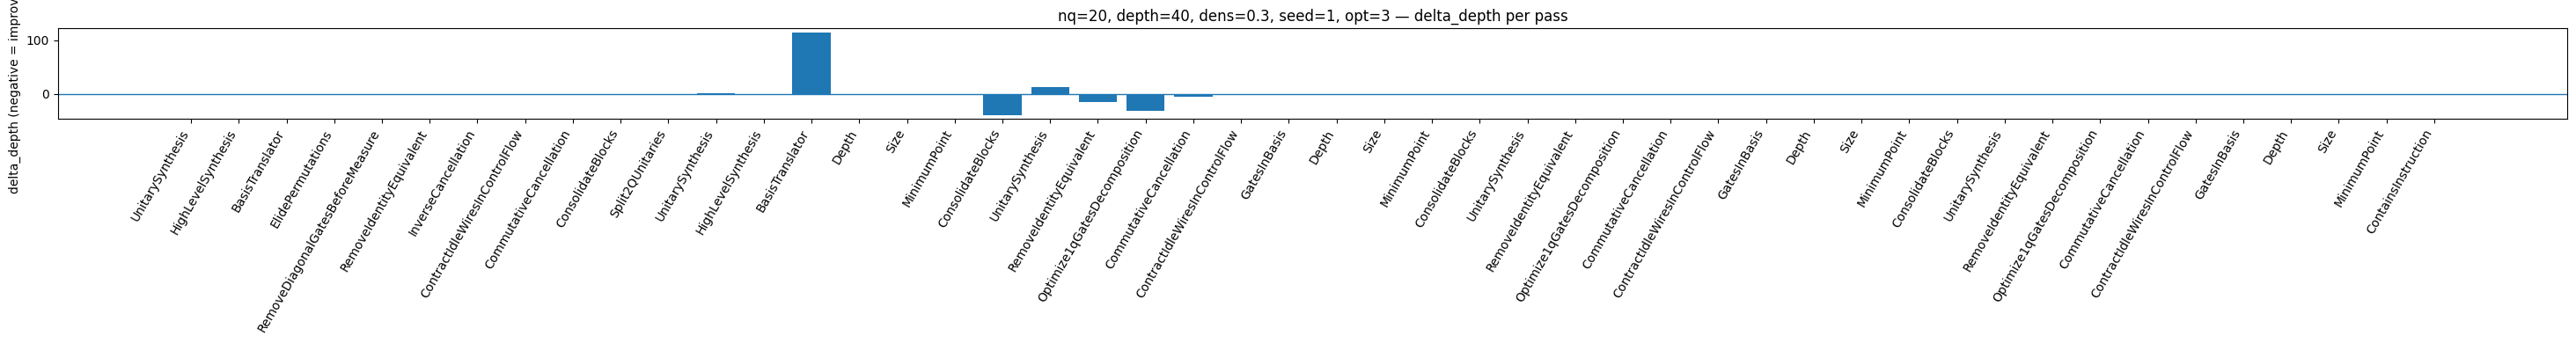


Top passes by delta_twoq (most negative first):
{'i': 18, 'pass': 'ConsolidateBlocks', 'delta_twoq': -24, 'delta_depth': -39, 'twoq': 156, 'depth': 129, 'time_sec': 0.0006020069122314453}
{'i': 7, 'pass': 'InverseCancellation', 'delta_twoq': -4, 'delta_depth': 0, 'twoq': 181, 'depth': 53, 'time_sec': 5.0067901611328125e-05}
{'i': 10, 'pass': 'ConsolidateBlocks', 'delta_twoq': -2, 'delta_depth': 0, 'twoq': 179, 'depth': 52, 'time_sec': 0.0004277229309082031}
{'i': 1, 'pass': 'UnitarySynthesis', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 185, 'depth': 53, 'time_sec': 3.0994415283203125e-06}
{'i': 2, 'pass': 'HighLevelSynthesis', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 185, 'depth': 53, 'time_sec': 5.245208740234375e-06}
{'i': 3, 'pass': 'BasisTranslator', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 185, 'depth': 53, 'time_sec': 9.298324584960938e-06}
{'i': 4, 'pass': 'ElidePermutations', 'delta_twoq': 0, 'delta_depth': 0, 'twoq': 185, 'depth': 53, 'time_sec': 3.0994415283203125e-06}
{

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.converters import dag_to_circuit

try:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
except Exception:
    from qiskit.transpiler import generate_preset_pass_manager  # type: ignore

TWOQ_NAMES = {"cx", "cz", "swap", "iswap", "ecr", "rxx", "ryy", "rzz"}


def random_cx_circuit(num_qubits: int, depth: int, cx_density: float, seed: int = 1) -> QuantumCircuit:
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(num_qubits)
    one_qubit_gates = ["rx", "ry", "rz", "h", "s", "t"]

    for _ in range(depth):
        available = list(range(num_qubits))
        rng.shuffle(available)
        i = 0
        while i < len(available):
            q = available[i]
            if (len(available) - i >= 2) and (rng.random() < cx_density):
                partner_idx = rng.integers(i + 1, len(available))
                q2 = available[partner_idx]
                available[i + 1], available[partner_idx] = available[partner_idx], available[i + 1]
                qc.cx(q, q2)
                i += 2
            else:
                gate = rng.choice(one_qubit_gates)
                if gate in ["rx", "ry", "rz"]:
                    theta = 2 * np.pi * rng.random()
                    getattr(qc, gate)(theta, q)
                else:
                    getattr(qc, gate)(q)
                i += 1
    return qc


def decompose_to_basis(circuit: QuantumCircuit, basis_gates=("cx", "rx", "ry", "rz"), optimization_level=0):
    basis = list(basis_gates)
    if "id" not in basis:
        basis.append("id")
    return transpile(circuit, basis_gates=basis, optimization_level=optimization_level)


def _count_twoq_in_dag(dag) -> int:
    return sum(1 for n in dag.op_nodes() if n.name.lower() in TWOQ_NAMES)


def run_with_callback_log(qc: QuantumCircuit, basis_gates=("rz", "sx", "x", "cx"), optimization_level: int = 3):
    pm = generate_preset_pass_manager(optimization_level=optimization_level, basis_gates=list(basis_gates))
    log = []

    def cb(*args, **kwargs):
        # 典型: (pass_, dag, time, property_set, count)
        pass_ = kwargs.get("pass_") if "pass_" in kwargs else (args[0] if len(args) > 0 else None)
        dag = kwargs.get("dag") if "dag" in kwargs else (args[1] if len(args) > 1 else None)
        t = kwargs.get("time") if "time" in kwargs else (args[2] if len(args) > 2 else None)
        count = kwargs.get("count") if "count" in kwargs else (args[4] if len(args) > 4 else None)

        if dag is None or pass_ is None:
            return

        try:
            twoq = _count_twoq_in_dag(dag)
            depth = dag.depth()
        except Exception:
            circ = dag_to_circuit(dag)
            ops = circ.count_ops()
            twoq = sum(int(ops.get(g, 0)) for g in TWOQ_NAMES)
            depth = circ.depth()

        name = pass_.name() if hasattr(pass_, "name") else pass_.__class__.__name__
        log.append(
            {
                "i": int(count) if count is not None else len(log),
                "pass": str(name),
                "twoq": int(twoq),
                "depth": int(depth),
                "time_sec": float(t) if t is not None else None,
            }
        )

    out = pm.run(qc, callback=cb)
    log = sorted(log, key=lambda r: r["i"])
    return out, log


def make_deltas(log):
    deltas = []
    for i in range(1, len(log)):
        prev, cur = log[i - 1], log[i]
        deltas.append(
            {
                "i": cur["i"],
                "pass": cur["pass"],
                "delta_twoq": cur["twoq"] - prev["twoq"],
                "delta_depth": cur["depth"] - prev["depth"],
                "twoq": cur["twoq"],
                "depth": cur["depth"],
                "time_sec": cur["time_sec"],
            }
        )
    return deltas


def plot_pass_stats(log, title="Qiskit pass profiling"):
    deltas = make_deltas(log)

    xs_log = list(range(len(log)))
    names_log = [r["pass"] for r in log]
    twoq = [r["twoq"] for r in log]
    depth = [r["depth"] for r in log]

    xs = list(range(len(deltas)))
    names = [r["pass"] for r in deltas]
    d2 = [r["delta_twoq"] for r in deltas]
    dd = [r["delta_depth"] for r in deltas]

    w = max(10, len(log) * 0.6)

    # twoq 推移
    plt.figure(figsize=(w, 4))
    plt.plot(xs_log, twoq, marker="o")
    plt.xticks(xs_log, names_log, rotation=60, ha="right")
    plt.ylabel("twoq (after pass)")
    plt.title(title + " — twoq progression")
    plt.tight_layout()

    # depth 推移
    plt.figure(figsize=(w, 4))
    plt.plot(xs_log, depth, marker="o")
    plt.xticks(xs_log, names_log, rotation=60, ha="right")
    plt.ylabel("depth (after pass)")
    plt.title(title + " — depth progression")
    plt.tight_layout()

    # delta_twoq
    plt.figure(figsize=(w, 4))
    plt.bar(xs, d2)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs, names, rotation=60, ha="right")
    plt.ylabel("delta_twoq (negative = improvement)")
    plt.title(title + " — delta_twoq per pass")
    plt.tight_layout()

    # delta_depth
    plt.figure(figsize=(w, 4))
    plt.bar(xs, dd)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs, names, rotation=60, ha="right")
    plt.ylabel("delta_depth (negative = improvement)")
    plt.title(title + " — delta_depth per pass")
    plt.tight_layout()

    plt.show()

    # 2Qが減ったパスを表示
    ranked = sorted(deltas, key=lambda r: r["delta_twoq"])
    print("\nTop passes by delta_twoq (most negative first):")
    for r in ranked[:10]:
        print(r)


# ---- ここだけ触ればOK（パラメータ） ----
nq = 20
depth = 40
dens = 0.3
seed = 1
opt_level = 3
pre_basis = ("cx", "rx", "ry", "rz")     # ランダム回路を一度この基底へ分解
target_basis = ("rz", "sx", "x", "cx")   # pass manager のターゲット基底

qc = random_cx_circuit(nq, depth, dens, seed=seed)
qc = decompose_to_basis(qc, basis_gates=pre_basis, optimization_level=0)

out, log = run_with_callback_log(qc, basis_gates=target_basis, optimization_level=opt_level)

print(f"final twoq/depth: {log[-1]['twoq']} {log[-1]['depth']}")
plot_pass_stats(log, title=f"nq={nq}, depth={depth}, dens={dens}, seed={seed}, opt={opt_level}")

In [6]:
def run_with_callback_log2(qc, basis_gates=("rz","sx","x","cx"), optimization_level=3):
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        basis_gates=list(basis_gates),
    )
    log = []

    def count_twoq(dag):
        return sum(1 for n in dag.op_nodes() if n.name.lower() in TWOQ_NAMES)

    def count_unitary2q(dag):
        return sum(1 for n in dag.op_nodes() if n.name.lower() == "unitary" and len(n.qargs) == 2)

    def cb(*args, **kwargs):
        pass_ = kwargs.get("pass_") if "pass_" in kwargs else (args[0] if len(args) > 0 else None)
        dag   = kwargs.get("dag")   if "dag"   in kwargs else (args[1] if len(args) > 1 else None)
        t     = kwargs.get("time")  if "time"  in kwargs else (args[2] if len(args) > 2 else None)
        count = kwargs.get("count") if "count" in kwargs else (args[4] if len(args) > 4 else None)
        if dag is None or pass_ is None:
            return

        name = pass_.name() if hasattr(pass_, "name") else pass_.__class__.__name__
        log.append({
            "i": int(count) if count is not None else len(log),
            "pass": str(name),
            "twoq": int(count_twoq(dag)),
            "unitary2q": int(count_unitary2q(dag)),
            "depth": int(dag.depth()),
            "time_sec": float(t) if t is not None else None,
        })

    out = pm.run(qc, callback=cb)
    log = sorted(log, key=lambda r: r["i"])
    return out, log

final twoq/depth: 184 88, unitary2q=0


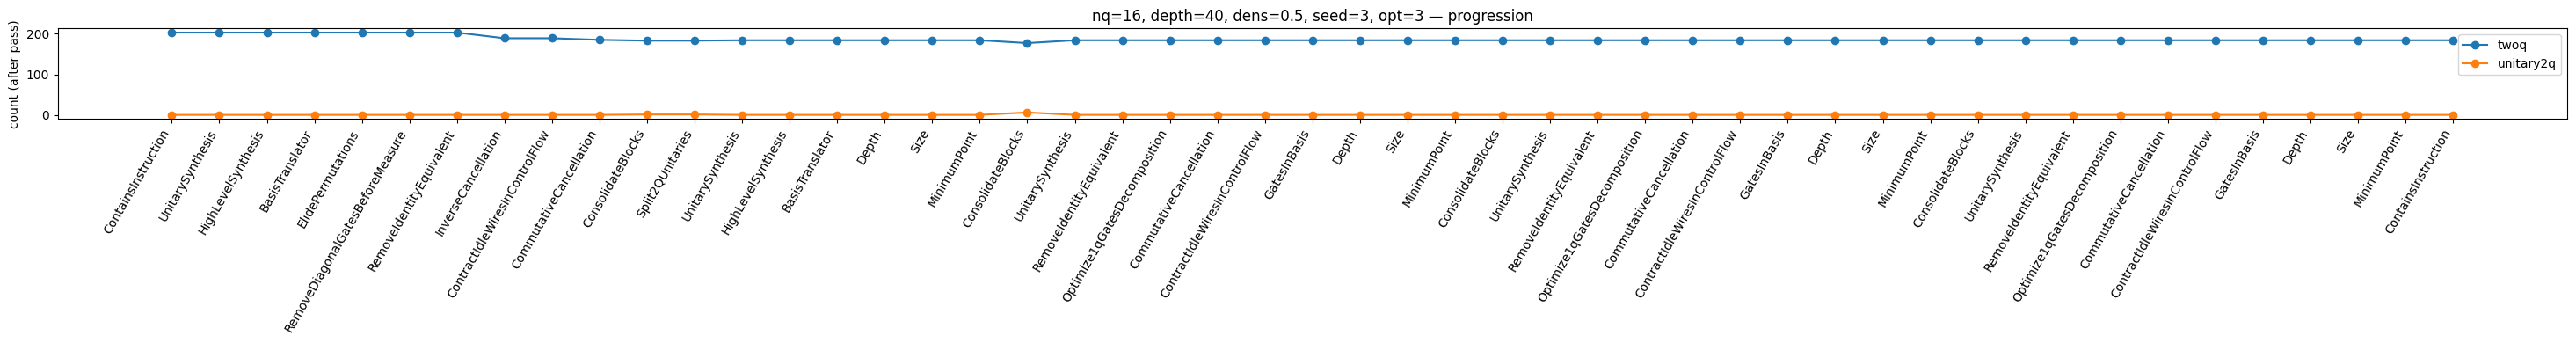

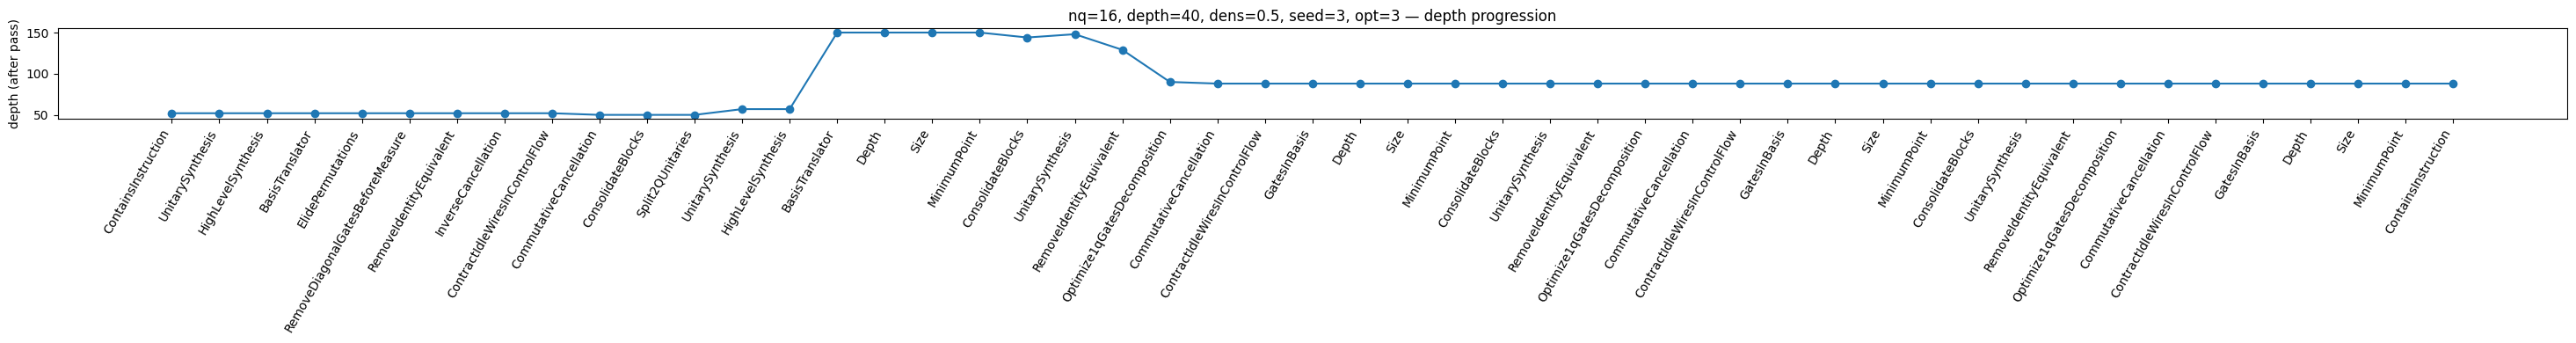

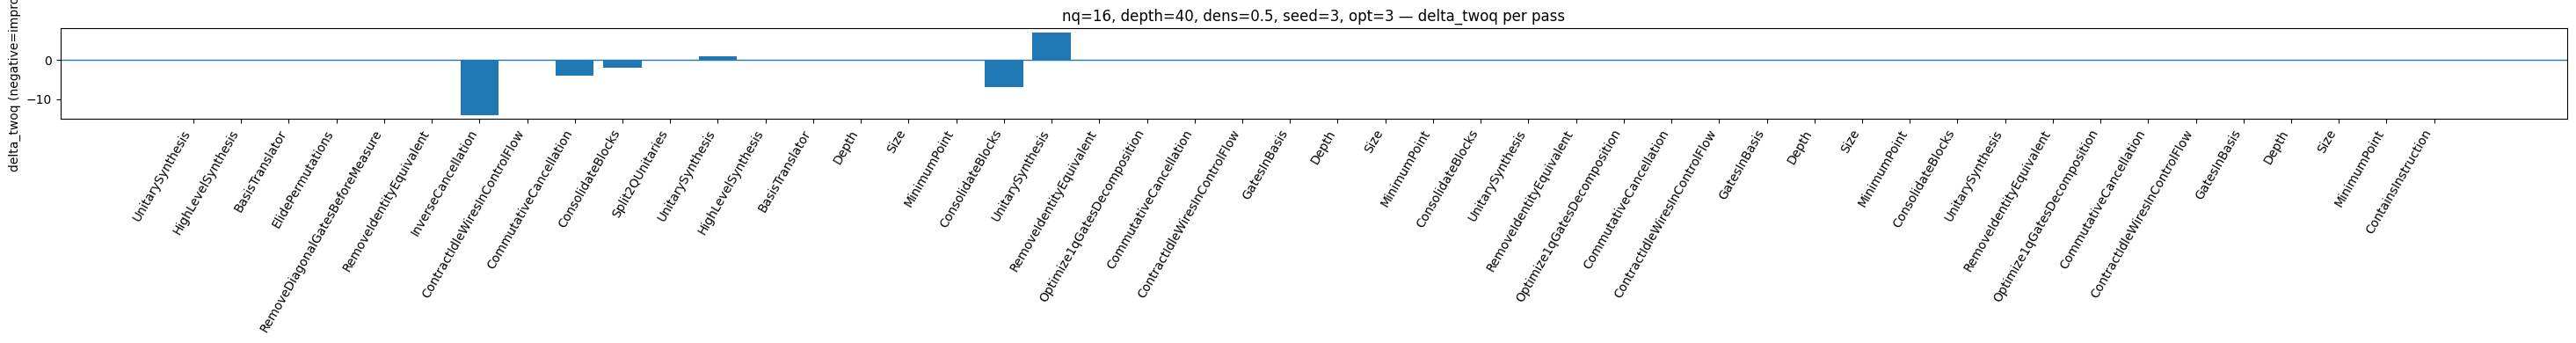

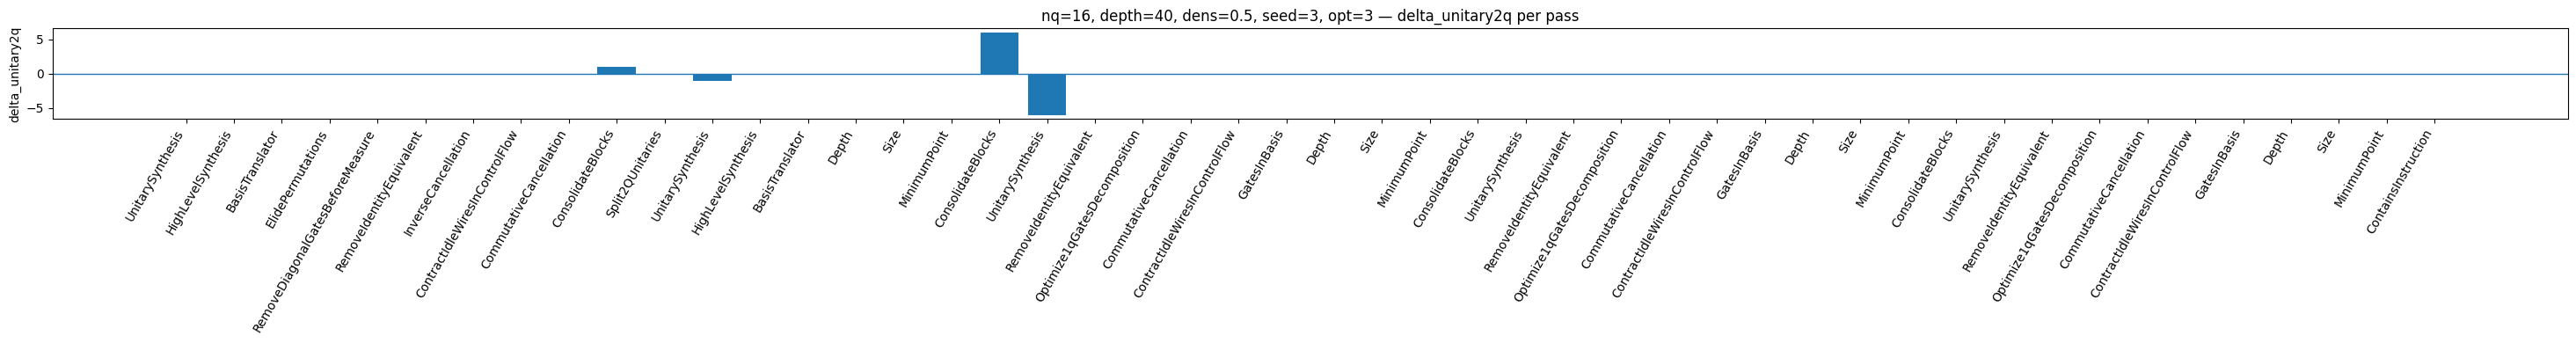

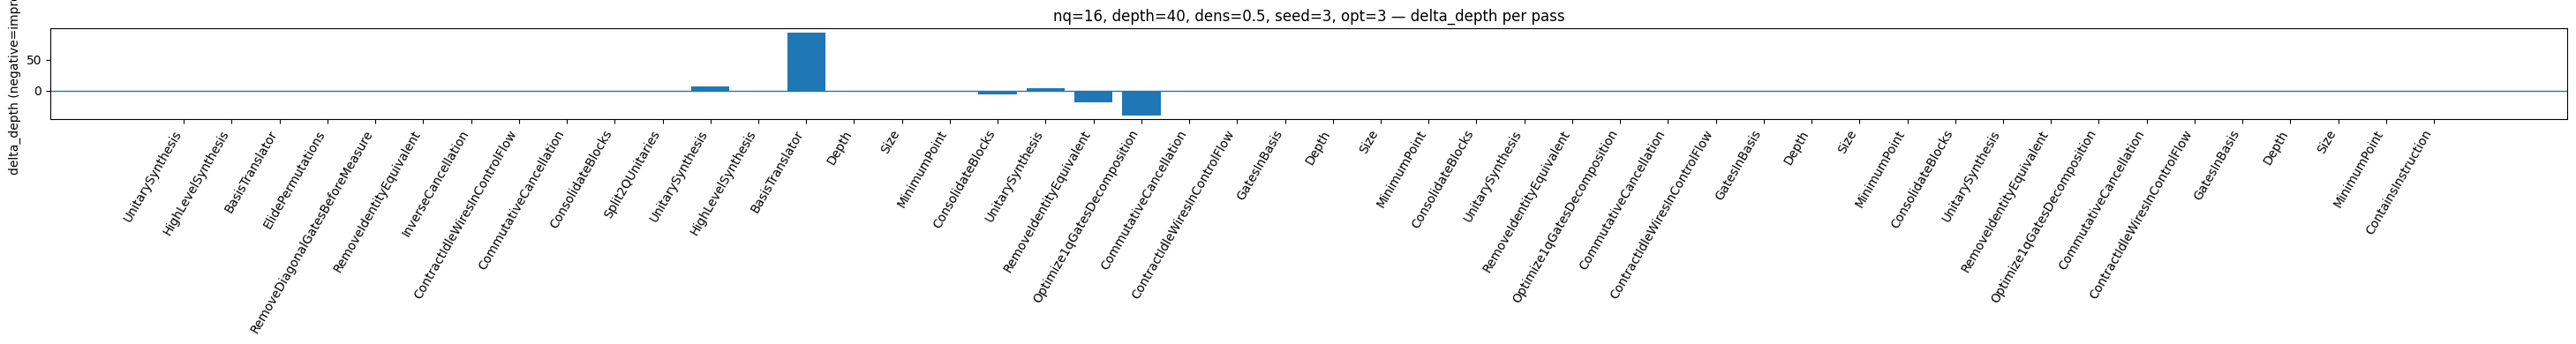


Top passes by delta_twoq (most negative first):
{'i': 7, 'pass': 'InverseCancellation', 'delta_twoq': -14, 'delta_unitary2q': 0, 'delta_depth': 0, 'twoq': 189, 'unitary2q': 0, 'depth': 52, 'time_sec': 4.8160552978515625e-05}
{'i': 18, 'pass': 'ConsolidateBlocks', 'delta_twoq': -7, 'delta_unitary2q': 6, 'delta_depth': -6, 'twoq': 177, 'unitary2q': 6, 'depth': 144, 'time_sec': 0.0005288124084472656}
{'i': 9, 'pass': 'CommutativeCancellation', 'delta_twoq': -4, 'delta_unitary2q': 0, 'delta_depth': -2, 'twoq': 185, 'unitary2q': 0, 'depth': 50, 'time_sec': 0.00023698806762695312}
{'i': 10, 'pass': 'ConsolidateBlocks', 'delta_twoq': -2, 'delta_unitary2q': 1, 'delta_depth': 0, 'twoq': 183, 'unitary2q': 1, 'depth': 50, 'time_sec': 0.0003998279571533203}
{'i': 1, 'pass': 'UnitarySynthesis', 'delta_twoq': 0, 'delta_unitary2q': 0, 'delta_depth': 0, 'twoq': 203, 'unitary2q': 0, 'depth': 52, 'time_sec': 2.1457672119140625e-06}
{'i': 2, 'pass': 'HighLevelSynthesis', 'delta_twoq': 0, 'delta_unitary2

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile

try:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
except Exception:
    from qiskit.transpiler import generate_preset_pass_manager  # type: ignore

TWOQ_NAMES = {"cx", "cz", "swap", "iswap", "ecr", "rxx", "ryy", "rzz"}


def random_cx_circuit(num_qubits: int, depth: int, cx_density: float, seed: int = 1) -> QuantumCircuit:
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(num_qubits)
    one_qubit_gates = ["rx", "ry", "rz", "h", "s", "t"]

    for _ in range(depth):
        available = list(range(num_qubits))
        rng.shuffle(available)
        i = 0
        while i < len(available):
            q = available[i]
            if (len(available) - i >= 2) and (rng.random() < cx_density):
                partner_idx = rng.integers(i + 1, len(available))
                q2 = available[partner_idx]
                available[i + 1], available[partner_idx] = available[partner_idx], available[i + 1]
                qc.cx(q, q2)
                i += 2
            else:
                gate = rng.choice(one_qubit_gates)
                if gate in ["rx", "ry", "rz"]:
                    theta = 2 * np.pi * rng.random()
                    getattr(qc, gate)(theta, q)
                else:
                    getattr(qc, gate)(q)
                i += 1
    return qc


def decompose_to_basis(circuit: QuantumCircuit, basis_gates=("cx", "rx", "ry", "rz"), optimization_level=0):
    basis = list(basis_gates)
    if "id" not in basis:
        basis.append("id")
    return transpile(circuit, basis_gates=basis, optimization_level=optimization_level)


def run_with_callback_log2(qc, basis_gates=("rz", "sx", "x", "cx"), optimization_level=3):
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        basis_gates=list(basis_gates),
    )
    log = []

    def count_twoq(dag):
        return sum(1 for n in dag.op_nodes() if n.name.lower() in TWOQ_NAMES)

    def count_unitary2q(dag):
        return sum(1 for n in dag.op_nodes() if n.name.lower() == "unitary" and len(n.qargs) == 2)

    def cb(*args, **kwargs):
        pass_ = kwargs.get("pass_") if "pass_" in kwargs else (args[0] if len(args) > 0 else None)
        dag   = kwargs.get("dag")   if "dag"   in kwargs else (args[1] if len(args) > 1 else None)
        t     = kwargs.get("time")  if "time"  in kwargs else (args[2] if len(args) > 2 else None)
        count = kwargs.get("count") if "count" in kwargs else (args[4] if len(args) > 4 else None)
        if dag is None or pass_ is None:
            return

        name = pass_.name() if hasattr(pass_, "name") else pass_.__class__.__name__
        log.append({
            "i": int(count) if count is not None else len(log),
            "pass": str(name),
            "twoq": int(count_twoq(dag)),
            "unitary2q": int(count_unitary2q(dag)),
            "depth": int(dag.depth()),
            "time_sec": float(t) if t is not None else None,
        })

    out = pm.run(qc, callback=cb)
    log = sorted(log, key=lambda r: r["i"])
    return out, log


def make_deltas(log):
    deltas = []
    for i in range(1, len(log)):
        prev, cur = log[i - 1], log[i]
        deltas.append({
            "i": cur["i"],
            "pass": cur["pass"],
            "delta_twoq": cur["twoq"] - prev["twoq"],
            "delta_unitary2q": cur["unitary2q"] - prev["unitary2q"],
            "delta_depth": cur["depth"] - prev["depth"],
            "twoq": cur["twoq"],
            "unitary2q": cur["unitary2q"],
            "depth": cur["depth"],
            "time_sec": cur["time_sec"],
        })
    return deltas


def plot_pass_stats2(log, title="Qiskit pass profiling (twoq + unitary2q)"):
    deltas = make_deltas(log)

    xs = list(range(len(log)))
    names = [r["pass"] for r in log]
    twoq = [r["twoq"] for r in log]
    u2 = [r["unitary2q"] for r in log]
    depth = [r["depth"] for r in log]

    xs_d = list(range(len(deltas)))
    names_d = [r["pass"] for r in deltas]
    d_twoq = [r["delta_twoq"] for r in deltas]
    d_u2 = [r["delta_unitary2q"] for r in deltas]
    d_depth = [r["delta_depth"] for r in deltas]

    w = max(10, len(log) * 0.6)

    # 推移：twoq / unitary2q
    plt.figure(figsize=(w, 4))
    plt.plot(xs, twoq, marker="o", label="twoq")
    plt.plot(xs, u2, marker="o", label="unitary2q")
    plt.xticks(xs, names, rotation=60, ha="right")
    plt.ylabel("count (after pass)")
    plt.title(title + " — progression")
    plt.legend()
    plt.tight_layout()

    # 推移：depth
    plt.figure(figsize=(w, 4))
    plt.plot(xs, depth, marker="o")
    plt.xticks(xs, names, rotation=60, ha="right")
    plt.ylabel("depth (after pass)")
    plt.title(title + " — depth progression")
    plt.tight_layout()

    # 差分：delta_twoq
    plt.figure(figsize=(w, 4))
    plt.bar(xs_d, d_twoq)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs_d, names_d, rotation=60, ha="right")
    plt.ylabel("delta_twoq (negative=improve)")
    plt.title(title + " — delta_twoq per pass")
    plt.tight_layout()

    # 差分：delta_unitary2q（ConsolidateBlocksの“圧縮”が見える）
    plt.figure(figsize=(w, 4))
    plt.bar(xs_d, d_u2)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs_d, names_d, rotation=60, ha="right")
    plt.ylabel("delta_unitary2q")
    plt.title(title + " — delta_unitary2q per pass")
    plt.tight_layout()

    # 差分：delta_depth
    plt.figure(figsize=(w, 4))
    plt.bar(xs_d, d_depth)
    plt.axhline(0, linewidth=1)
    plt.xticks(xs_d, names_d, rotation=60, ha="right")
    plt.ylabel("delta_depth (negative=improve)")
    plt.title(title + " — delta_depth per pass")
    plt.tight_layout()

    plt.show()

    ranked = sorted(deltas, key=lambda r: r["delta_twoq"])
    print("\nTop passes by delta_twoq (most negative first):")
    for r in ranked[:10]:
        print(r)


# --------- ここだけ調整 ---------
nq = 16
depth = 40
dens = 0.5
seed = 3
opt_level = 3
pre_basis = ("cx", "rx", "ry", "rz")
target_basis = ("rz", "sx", "x", "cx")

qc = random_cx_circuit(nq, depth, dens, seed=seed)
qc = decompose_to_basis(qc, basis_gates=pre_basis, optimization_level=0)

out, log = run_with_callback_log2(qc, basis_gates=target_basis, optimization_level=opt_level)

print(f"final twoq/depth: {log[-1]['twoq']} {log[-1]['depth']}, unitary2q={log[-1]['unitary2q']}")
plot_pass_stats2(log, title=f"nq={nq}, depth={depth}, dens={dens}, seed={seed}, opt={opt_level}")

In [8]:
def show_window(log, center_i, radius=3):
    # log: [{'i','pass','twoq','unitary2q','depth',...}, ...]  (i順にsort済み前提)
    idx_map = {r["i"]: k for k, r in enumerate(log)}
    if center_i not in idx_map:
        print("center_i not found")
        return
    c = idx_map[center_i]
    lo = max(0, c - radius)
    hi = min(len(log), c + radius + 1)
    for r in log[lo:hi]:
        print(f'i={r["i"]:>3}  {r["pass"]:<28} twoq={r["twoq"]:<4} unitary2q={r["unitary2q"]:<3} depth={r["depth"]}')

In [9]:
show_window(log, center_i=18, radius=6)

i= 12  UnitarySynthesis             twoq=184  unitary2q=0   depth=57
i= 13  HighLevelSynthesis           twoq=184  unitary2q=0   depth=57
i= 14  BasisTranslator              twoq=184  unitary2q=0   depth=150
i= 15  Depth                        twoq=184  unitary2q=0   depth=150
i= 16  Size                         twoq=184  unitary2q=0   depth=150
i= 17  MinimumPoint                 twoq=184  unitary2q=0   depth=150
i= 18  ConsolidateBlocks            twoq=177  unitary2q=6   depth=144
i= 19  UnitarySynthesis             twoq=184  unitary2q=0   depth=148
i= 20  RemoveIdentityEquivalent     twoq=184  unitary2q=0   depth=129
i= 21  Optimize1qGatesDecomposition twoq=184  unitary2q=0   depth=90
i= 22  CommutativeCancellation      twoq=184  unitary2q=0   depth=88
i= 23  ContractIdleWiresInControlFlow twoq=184  unitary2q=0   depth=88
i= 24  GatesInBasis                 twoq=184  unitary2q=0   depth=88


In [10]:
import sys, os, importlib

# notebook と同じ階層に circuit_opt.py がある前提。
# もし違う場合は、そのディレクトリを追加してください。
# 例) sys.path.append("/path/to/your/project")

import circuit_opt
importlib.reload(circuit_opt)

# ちゃんと追加されているか確認
print("has cancel_twoq_only:", hasattr(circuit_opt, "cancel_twoq_only"))
print("has zx_local_search_min_cost_with_cancel:", hasattr(circuit_opt, "zx_local_search_min_cost_with_cancel"))

has cancel_twoq_only: True
has zx_local_search_min_cost_with_cancel: True


In [11]:
import numpy as np
from qiskit import QuantumCircuit, transpile

# ランダム回路（benchmark.pyと同等のやつを簡易に）
def random_cx_circuit(num_qubits: int, depth: int, cx_density: float, seed: int = 1) -> QuantumCircuit:
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(num_qubits)
    one_qubit_gates = ["rx", "ry", "rz", "h", "s", "t"]
    for _ in range(depth):
        available = list(range(num_qubits))
        rng.shuffle(available)
        i = 0
        while i < len(available):
            q = available[i]
            if (len(available) - i >= 2) and (rng.random() < cx_density):
                partner_idx = rng.integers(i + 1, len(available))
                q2 = available[partner_idx]
                available[i + 1], available[partner_idx] = available[partner_idx], available[i + 1]
                qc.cx(q, q2)
                i += 2
            else:
                gate = rng.choice(one_qubit_gates)
                if gate in ["rx", "ry", "rz"]:
                    theta = 2 * np.pi * rng.random()
                    getattr(qc, gate)(theta, q)
                else:
                    getattr(qc, gate)(q)
                i += 1
    return qc

# ---- パラメータ ----
nq = 16
depth = 40
dens = 0.5
seed = 3
processors = 4

# sizes（均等割）
base_size = nq // processors
rem = nq % processors
sizes = [base_size + (1 if i < rem else 0) for i in range(processors)]

qc = random_cx_circuit(nq, depth, dens, seed=seed)

# まずは比較の出発点を揃えるため、適当に basis 化（あなたの bench に合わせるならここは同じに）
qc0 = transpile(qc, basis_gates=["cx", "rx", "ry", "rz", "id"], optimization_level=0)

# 新フロー実行（trial評価前に cancellation を挟む）
best_qc, best_part, stats = circuit_opt.zx_local_search_min_cost_with_cancel(
    qc0,
    sizes=sizes,
    w_remote=5.0,
    w_local=1.0,
    max_outer_iters=3,
    max_moves_per_pass=50,
    cancel_each_trial=True,
    cancel_on_accept=False,
)

print("stats:", stats)

# 2Q/remote/eff_cost を確認
G0 = circuit_opt.build_interaction_graph(qc0)
part0 = circuit_opt.kway_partition(G0, sizes)
cost0, rem0, loc0 = circuit_opt.eff_cost(qc0, part0, w_remote=5.0, w_local=1.0)

G1 = circuit_opt.build_interaction_graph(best_qc)
part1 = circuit_opt.kway_partition(G1, sizes)
cost1, rem1, loc1 = circuit_opt.eff_cost(best_qc, part1, w_remote=5.0, w_local=1.0)

print("eff_cost:", cost0, "->", cost1)
print("remote/local:", (rem0, loc0), "->", (rem1, loc1))
print("twoq:", circuit_opt.count_two_qubit_gates(qc0), "->", circuit_opt.count_two_qubit_gates(best_qc))
print("depth:", qc0.depth(), "->", best_qc.depth())

stats: {'eff_cost_initial': 835.0, 'remote_initial': 158.0, 'local_initial': 45.0, 'num_accepts': 0.0, 'num_trials': 0.0, 'num_cancel_calls': 0.0, 'eff_cost_final': 835.0, 'remote_final': 158.0, 'local_final': 45.0}
eff_cost: 835.0 -> 835.0
remote/local: (158, 45) -> (158, 45)
twoq: 203 -> 203
depth: 52 -> 52


In [12]:
import importlib
import circuit_opt
importlib.reload(circuit_opt)

import numpy as np
from qiskit import QuantumCircuit, transpile

def random_cx_circuit(num_qubits: int, depth: int, cx_density: float, seed: int = 1) -> QuantumCircuit:
    rng = np.random.default_rng(seed)
    qc = QuantumCircuit(num_qubits)
    one_qubit_gates = ["rx", "ry", "rz", "h", "s", "t"]

    for _ in range(depth):
        available = list(range(num_qubits))
        rng.shuffle(available)
        i = 0
        while i < len(available):
            q = available[i]
            if (len(available) - i >= 2) and (rng.random() < cx_density):
                partner_idx = rng.integers(i + 1, len(available))
                q2 = available[partner_idx]
                available[i + 1], available[partner_idx] = available[partner_idx], available[i + 1]
                qc.cx(q, q2)
                i += 2
            else:
                gate = rng.choice(one_qubit_gates)
                if gate in ["rx", "ry", "rz"]:
                    theta = 2 * np.pi * rng.random()
                    getattr(qc, gate)(theta, q)
                else:
                    getattr(qc, gate)(q)
                i += 1
    return qc

In [13]:
TWOQ = ("cx","cz","iswap","ecr","rxx","ryy","rzz","swap")

def make_sizes(nq: int, processors: int):
    p = min(processors, nq)
    base = nq // p
    rem = nq % p
    return [base + (1 if i < rem else 0) for i in range(p)]

def eval_metrics(qc, sizes, w_remote=5.0, w_local=1.0):
    G = circuit_opt.build_interaction_graph(qc, twoq_names=TWOQ)
    part = circuit_opt.kway_partition(G, sizes)
    cost, remote, local = circuit_opt.eff_cost(qc, part, w_remote=w_remote, w_local=w_local, twoq_names=TWOQ)
    twoq = circuit_opt.count_two_qubit_gates(qc, twoq_names=TWOQ)
    depth = qc.depth()
    return {"eff_cost": cost, "remote": remote, "local": local, "twoq": twoq, "depth": depth}

def pretty(label, m):
    return f"{label:>10} | eff={m['eff_cost']:>8.1f}  remote={m['remote']:>4}  local={m['local']:>4}  twoq={m['twoq']:>4}  depth={m['depth']:>4}"

In [ ]:
def duel_once(
    nq=16, depth=40, dens=0.5, seed=1,
    processors=4,
    target_basis=("rz","sx","x","cx"),
    w_remote=5.0, w_local=1.0,
    zx_outer=3, zx_moves=50,
    check_equiv=False,
):
    sizes = make_sizes(nq, processors)

    # --- 出発点を揃える（opt=0 + basis固定）
    qc = random_cx_circuit(nq, depth, dens, seed=seed)
    qc0 = transpile(qc, basis_gates=["cx","rx","ry","rz","id"], optimization_level=0)

    # --- Qiskit baseline（opt=3）
    qisk = transpile(qc0, basis_gates=list(target_basis)+["id"], optimization_level=3)

    # --- Your flow（ZX local search + trial cancellation）→ 最後に同じ基底へ整理
    best_qc, best_part, stats = circuit_opt.zx_local_search_min_cost_with_cancel(
        qc0,
        sizes=sizes,
        w_remote=w_remote,
        w_local=w_local,
        max_outer_iters=zx_outer,
        max_moves_per_pass=zx_moves,
        cancel_each_trial=True,
        cancel_on_accept=False,
        twoq_names=TWOQ,
    )
    yours = transpile(best_qc, basis_gates=list(target_basis)+["id"], optimization_level=3)

    # --- 評価（同じ sizes で毎回 partition を引き直して測る）
    m0 = eval_metrics(qc0, sizes, w_remote, w_local)
    mq = eval_metrics(qisk, sizes, w_remote, w_local)
    my = eval_metrics(yours, sizes, w_remote, w_local)

    print(f"seed={seed}  nq={nq} depth={depth} dens={dens}  processors={processors} sizes={sizes}")
    print(pretty("start", m0))
    print(pretty("qiskit", mq))
    print(pretty("yours", my))
    print("zx stats:", stats)

    # 等価性チェック（大きいと厳しいのでprobe）

    if check_equiv:
        if nq <= 10:
            ok, dist = circuit_opt.unitary_equiv(qc0, yours)
            print("equiv exact:", ok, "dist:", dist)
        else:
            ok = circuit_opt.fast_equiv_probe(qc0, yours, shots=64, seed=seed)
            print("equiv probe:", ok)

    return {"start": m0, "qiskit": mq, "yours": my, "zx_stats": stats}

In [ ]:
res = duel_once(nq=16, depth=40, dens=0.5, seed=3, processors=4)

seed=3  nq=16 depth=40 dens=0.5  processors=4 sizes=[4, 4, 4, 4]
     start | eff=   835.0  remote= 158  local=  45  twoq= 203  depth=  52
    qiskit | eff=   756.0  remote= 143  local=  41  twoq= 184  depth=  88
     yours | eff=   756.0  remote= 143  local=  41  twoq= 184  depth=  88
zx stats: {'eff_cost_initial': 835.0, 'remote_initial': 158.0, 'local_initial': 45.0, 'num_accepts': 0.0, 'num_trials': 0.0, 'num_cancel_calls': 0.0, 'eff_cost_final': 835.0, 'remote_final': 158.0, 'local_final': 45.0}


In [ ]:
def duel_many(
    trials=10,
    nq=16, depth=40, dens=0.5,
    processors=4,
    w_remote=5.0, w_local=1.0,
    seed0=1,
):
    wins_eff = 0
    wins_remote = 0
    wins_twoq = 0

    deltas = []
    for t in range(trials):
        seed = seed0 + t
        r = duel_once(
            nq=nq, depth=depth, dens=dens, seed=seed,
            processors=processors,
            w_remote=w_remote, w_local=w_local
        )
        mq, my = r["qiskit"], r["yours"]

        if my["eff_cost"] < mq["eff_cost"]:
            wins_eff += 1
        if my["remote"] < mq["remote"]:
            wins_remote += 1
        if my["twoq"] < mq["twoq"]:
            wins_twoq += 1

        deltas.append({
            "seed": seed,
            "eff_yours-qisk": my["eff_cost"] - mq["eff_cost"],
            "remote_yours-qisk": my["remote"] - mq["remote"],
            "twoq_yours-qisk": my["twoq"] - mq["twoq"],
            "depth_yours-qisk": my["depth"] - mq["depth"],
        })

    print("\n=== summary ===")
    print(f"wins (eff_cost): {wins_eff}/{trials}")
    print(f"wins (remote)  : {wins_remote}/{trials}")
    print(f"wins (twoq)    : {wins_twoq}/{trials}")
    return deltas

deltas = duel_many(trials=5, nq=16, depth=40, dens=0.5, processors=4, seed0=1)
deltas[:3]